# Dataset Inspection

In [1]:
import pandas as pd

In [2]:
obs_raw = pd.read_parquet("../data/raw/observations.parquet")
obs_raw.head()

,observation_id,observation_uri,quality_grade,observation_license_code,predator_prey_role,taxon_id,taxon_name,taxon_rank,preferred_common_name,latitude,...,class_id,class_name,order_id,order_name,family_id,family_name,genus_id,genus_name,species_id,species_name
0,55574,http://www.inaturalist.org/observations/55574,research,cc-by,eater,125194,Korthalsella complanata,species,Kaumahana,21.317598,...,47124.0,Magnoliopsida,49669.0,Santalales,59992.0,Santalaceae,125196.0,Korthalsella,125194.0,Korthalsella complanata
1,55575,http://www.inaturalist.org/observations/55575,research,cc-by,organism being eaten,169519,Syzygium sandwicense,species,ʻōhiʻa ha,21.317598,...,47124.0,Magnoliopsida,47791.0,Myrtales,51816.0,Myrtaceae,72388.0,Syzygium,169519.0,Syzygium sandwicense
2,338604,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,eater,1986,Geococcyx californianus,species,Greater Roadrunner,25.557155,...,3.0,Aves,1623.0,Cuculiformes,1627.0,Cuculidae,1985.0,Geococcyx,1986.0,Geococcyx californianus
3,414645,http://www.inaturalist.org/observations/414645,research,cc-by,eater,29508,Lycophidion capense,species,Cape Wolf Snake,-15.836848,...,26036.0,Reptilia,26172.0,Squamata,85853.0,Lamprophiidae,29507.0,Lycophidion,29508.0,Lycophidion capense
4,414707,http://www.inaturalist.org/observations/414707,research,cc-by,thing being eaten,37932,Mochlus sundevallii,species,Sundevall's Writhing Skink,-15.836848,...,26036.0,Reptilia,26172.0,Squamata,36982.0,Scincidae,37931.0,Mochlus,37932.0,Mochlus sundevallii


In [3]:
obs = obs_raw.copy()

In [4]:
obs.shape


(10387, 31)

In [5]:
obs.info()

<class 'pandas.DataFrame'>
RangeIndex: 10387 entries, 0 to 10386
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   observation_id            10387 non-null  int64  
 1   observation_uri           10387 non-null  str    
 2   quality_grade             10387 non-null  str    
 3   observation_license_code  10387 non-null  str    
 4   predator_prey_role        10234 non-null  str    
 5   taxon_id                  10387 non-null  int64  
 6   taxon_name                10387 non-null  str    
 7   taxon_rank                10387 non-null  str    
 8   preferred_common_name     9449 non-null   str    
 9   latitude                  10371 non-null  float64
 10  longitude                 10371 non-null  float64
 11  positional_accuracy       8165 non-null   float64
 12  country                   0 non-null      object 
 13  state                     0 non-null      object 
 14  county           

- Since country, state, county, town has 0 values. hence deleting the columns
- Delete all id taxonomic_level_id columns such as "kingdom_id", "phylum_id", "class_id", "order_id", "family_id", "genus_id", "species_id", "taxon_id"

# Validation

In [6]:
obs.columns

Index(['observation_id', 'observation_uri', 'quality_grade',
       'observation_license_code', 'predator_prey_role', 'taxon_id',
       'taxon_name', 'taxon_rank', 'preferred_common_name', 'latitude',
       'longitude', 'positional_accuracy', 'country', 'state', 'county',
       'town', 'photo_count', 'kingdom_id', 'kingdom_name', 'phylum_id',
       'phylum_name', 'class_id', 'class_name', 'order_id', 'order_name',
       'family_id', 'family_name', 'genus_id', 'genus_name', 'species_id',
       'species_name'],
      dtype='str')

### taxon_rank distribution

In [7]:
# Taxon_rank types
un_taxon_ranks = obs["taxon_rank"].value_counts()
# un_taxon_ranks[~(un_taxon_ranks.index == "species")]
un_taxon_ranks

taxon_rank
species       9149
subspecies     962
genus          123
variety         50
hybrid          46
complex         25
subgenus        12
tribe           11
subfamily        6
form             3
Name: count, dtype: int64

In [8]:
# count of records where taxon_rank is not equal to "species"
obs[obs["taxon_rank"] != "species"].shape[0]

1238

In [9]:
# Check if the df has requried taxon ranks
different_taxon_rank = [
    "complex",
    "subspecies",
    "subfamily",
    "genus",
    "hybrid",
    "form",
    "subgenus",
    "variety",
    "tribe",
]
not_species_ranks = obs[obs["taxon_rank"].isin(different_taxon_rank)][
    [
        "observation_id",
        "taxon_rank",
        "taxon_name",
        "kingdom_name",
        "phylum_name",
        "class_name",
        "order_name",
        "genus_name",
        "species_name",
    ]
]
not_species_ranks[not_species_ranks["taxon_rank"] == "tribe"]

,observation_id,taxon_rank,taxon_name,kingdom_name,phylum_name,class_name,order_name,genus_name,species_name
3295,155356270,tribe,Coriarachnini,Animalia,Arthropoda,Arachnida,Araneae,NaN,NaN
3444,164717774,tribe,Misumenini,Animalia,Arthropoda,Arachnida,Araneae,NaN,NaN
3478,166530832,tribe,Syrphini,Animalia,Arthropoda,Insecta,Diptera,NaN,NaN
6168,258151521,tribe,Misumenini,Animalia,Arthropoda,Arachnida,Araneae,NaN,NaN
6247,261666243,tribe,Aspidiotini,Animalia,Arthropoda,Insecta,Hemiptera,NaN,NaN
6341,264989597,tribe,Aspidiotini,Animalia,Arthropoda,Insecta,Hemiptera,NaN,NaN
6377,266453070,tribe,Aspidiotini,Animalia,Arthropoda,Insecta,Hemiptera,NaN,NaN
6709,285504635,tribe,Misumenini,Animalia,Arthropoda,Arachnida,Araneae,NaN,NaN
7547,312197095,tribe,Macrosiphini,Animalia,Arthropoda,Insecta,Hemiptera,NaN,NaN
7591,313706305,tribe,Aphidiini,Animalia,Arthropoda,Insecta,Hymenoptera,NaN,NaN


In [10]:
not_species_ranks.info()

<class 'pandas.DataFrame'>
Index: 1238 entries, 7 to 10381
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   observation_id  1238 non-null   int64
 1   taxon_rank      1238 non-null   str  
 2   taxon_name      1238 non-null   str  
 3   kingdom_name    1238 non-null   str  
 4   phylum_name     1238 non-null   str  
 5   class_name      1237 non-null   str  
 6   order_name      1237 non-null   str  
 7   genus_name      1221 non-null   str  
 8   species_name    1015 non-null   str  
dtypes: int64(1), str(8)
memory usage: 207.9 KB


### Renaming columns and identify missing columns

In [11]:
# check if the df has requried columns
requried_columns = [
    "observation_id",
    "taxon_rank",
    "taxon_name",
    "kingdom_name",
    "phylum_name",
    "class_name",
    "order_name",
    "genus_name",
    "species_name",
    "predator_prey_role",
]
missing_columns = [col for col in requried_columns if col not in obs.columns]
missing_columns

[]

In [12]:
# Renaming the columns
new_names = {
    "taxon_name": "scientific_name",
    "observation_id": "obs_id",
    "observation_uri": "obs_url",
    "observation_license_code": "obs_license_code",
    "preferred_common_name": "common_name",
}
obs = obs.rename(columns=new_names)
obs.columns


Index(['obs_id', 'obs_url', 'quality_grade', 'obs_license_code',
       'predator_prey_role', 'taxon_id', 'scientific_name', 'taxon_rank',
       'common_name', 'latitude', 'longitude', 'positional_accuracy',
       'country', 'state', 'county', 'town', 'photo_count', 'kingdom_id',
       'kingdom_name', 'phylum_id', 'phylum_name', 'class_id', 'class_name',
       'order_id', 'order_name', 'family_id', 'family_name', 'genus_id',
       'genus_name', 'species_id', 'species_name'],
      dtype='str')

### We are collapsing this category in taxon_rank into new columns and storing the scientific_name

In [13]:
ranks = not_species_ranks["taxon_rank"].unique()

for rank in ranks:
    name = f"{rank}_name"
    obs[name] = obs["scientific_name"].where(obs["taxon_rank"] == rank)


In [14]:
obs[obs["taxon_rank"] == "complex"].head()

,obs_id,obs_url,quality_grade,obs_license_code,predator_prey_role,taxon_id,scientific_name,taxon_rank,common_name,latitude,...,species_id,species_name,subspecies_name,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name
401,21482786,https://www.inaturalist.org/observations/21482786,research,cc-by-nc,eater,894751,Laphria canis,complex,NaN,36.074955,...,NaN,NaN,NaN,NaN,NaN,Laphria canis,NaN,NaN,NaN,NaN
735,51770782,https://www.inaturalist.org/observations/51770782,research,cc-by-nc,NaN,1507448,Xysticus cristatus,complex,NaN,48.172918,...,NaN,NaN,NaN,NaN,NaN,Xysticus cristatus,NaN,NaN,NaN,NaN
1762,83172924,https://www.inaturalist.org/observations/83172924,research,cc-by-nc,eater,1068886,Leptotes pirithous,complex,Common Zebra Blue Complex,-28.353300,...,NaN,NaN,NaN,NaN,NaN,Leptotes pirithous,NaN,NaN,NaN,NaN
3004,143252526,https://www.inaturalist.org/observations/14325...,research,cc-by,eater,1321226,Formica rufa,complex,rufa-group Wood Ants,53.354424,...,NaN,NaN,NaN,NaN,NaN,Formica rufa,NaN,NaN,NaN,NaN
3609,172583862,https://www.inaturalist.org/observations/17258...,research,cc-by-nc,eater,1255692,Enoplognatha ovata,complex,Candy-striped Spider complex,47.698782,...,NaN,NaN,NaN,NaN,NaN,Enoplognatha ovata,NaN,NaN,NaN,NaN


### Deleting columns

In [15]:
obs.columns

Index(['obs_id', 'obs_url', 'quality_grade', 'obs_license_code',
       'predator_prey_role', 'taxon_id', 'scientific_name', 'taxon_rank',
       'common_name', 'latitude', 'longitude', 'positional_accuracy',
       'country', 'state', 'county', 'town', 'photo_count', 'kingdom_id',
       'kingdom_name', 'phylum_id', 'phylum_name', 'class_id', 'class_name',
       'order_id', 'order_name', 'family_id', 'family_name', 'genus_id',
       'genus_name', 'species_id', 'species_name', 'subspecies_name',
       'subfamily_name', 'hybrid_name', 'complex_name', 'form_name',
       'subgenus_name', 'variety_name', 'tribe_name'],
      dtype='str')

In [16]:
clean_obs = obs.drop(
    columns=[
        "taxon_id",
        "country",
        "state",
        "county",
        "town",
        "kingdom_id",
        "phylum_id",
        "class_id",
        "order_id",
        "family_id",
        "genus_id",
        "species_id",
    ]
)
clean_obs

,obs_id,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,common_name,latitude,longitude,...,genus_name,species_name,subspecies_name,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name
0,55574,http://www.inaturalist.org/observations/55574,research,cc-by,eater,Korthalsella complanata,species,Kaumahana,21.317598,-157.743287,...,NaN,Korthalsella complanata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55575,http://www.inaturalist.org/observations/55575,research,cc-by,organism being eaten,Syzygium sandwicense,species,ʻōhiʻa ha,21.317598,-157.743287,...,NaN,Syzygium sandwicense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,338604,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,eater,Geococcyx californianus,species,Greater Roadrunner,25.557155,-103.453939,...,NaN,Geococcyx californianus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,414645,http://www.inaturalist.org/observations/414645,research,cc-by,eater,Lycophidion capense,species,Cape Wolf Snake,-15.836848,29.146428,...,NaN,Lycophidion capense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,414707,http://www.inaturalist.org/observations/414707,research,cc-by,thing being eaten,Mochlus sundevallii,species,Sundevall's Writhing Skink,-15.836848,29.146428,...,NaN,Mochlus sundevallii,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10382,402894441,https://www.inaturalist.org/observations/40289...,research,cc-by-nc,eater,Tenodera sinensis,species,Chinese Mantis,42.521747,-71.315875,...,NaN,Tenodera sinensis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10383,402958990,https://www.inaturalist.org/observations/40295...,research,cc-by-nc,organism being eaten,Arctotheca calendula,species,Capeweed,-37.806092,145.523925,...,NaN,Arctotheca calendula,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10384,402961424,https://www.inaturalist.org/observations/40296...,research,cc-by-nc,eater,Cyprotides cyprotus,species,Copper Trident-Blue,-33.657521,151.236569,...,NaN,Cyprotides cyprotus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10385,402961544,https://www.inaturalist.org/observations/40296...,research,cc-by-nc,eater,Vanessa kershawi,species,Australian Painted Lady,-33.657229,151.237746,...,NaN,Vanessa kershawi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
clean_obs.columns

Index(['obs_id', 'obs_url', 'quality_grade', 'obs_license_code',
       'predator_prey_role', 'scientific_name', 'taxon_rank', 'common_name',
       'latitude', 'longitude', 'positional_accuracy', 'photo_count',
       'kingdom_name', 'phylum_name', 'class_name', 'order_name',
       'family_name', 'genus_name', 'species_name', 'subspecies_name',
       'subfamily_name', 'hybrid_name', 'complex_name', 'form_name',
       'subgenus_name', 'variety_name', 'tribe_name'],
      dtype='str')

### Any unlicensed observations

In [18]:
# Check if there is any licensed images in the dataset
obs_license_distribution = clean_obs["obs_license_code"].value_counts().reset_index()
obs_license_distribution

,obs_license_code,count
0,cc-by-nc,6347
1,cc-by,3212
2,cc0,543
3,cc-by-nc-nd,132
4,cc-by-nc-sa,113
5,cc-by-sa,36
6,cc-by-nd,4


In [19]:
obs_license_distribution["obs_license_code"].unique()

<ArrowStringArray>
[   'cc-by-nc',       'cc-by',         'cc0', 'cc-by-nc-nd', 'cc-by-nc-sa',
    'cc-by-sa',    'cc-by-nd']
Length: 7, dtype: str

In [20]:
supported_licenses = [
    "cc-by-nc",
    "cc-by-sa",
    "cc-by-nd",
    "cc-by",
    "cc-by-nc",
    "cc-by-nc-sa",
    "cc-by-nc-nd",
    "cc0",
]
unsupported_licenses_count = obs.loc[
    ~obs["obs_license_code"].isin(supported_licenses), "obs_license_code"
].count()
print(f"Unsupported licenses count: {unsupported_licenses_count}")

Unsupported licenses count: 0


### Quality grade 

In [21]:
# Do we have any quality grades other than research grade
clean_obs["quality_grade"].unique()

<ArrowStringArray>
['research']
Length: 1, dtype: str

## Normalize the predator prey role category

In [22]:
clean_obs["predator_prey_role"].unique()

<ArrowStringArray>
['eater', 'organism being eaten', 'thing being eaten', nan]
Length: 4, dtype: str

In [23]:
clean_obs["predator_prey_role"].info()

<class 'pandas.Series'>
RangeIndex: 10387 entries, 0 to 10386
Series name: predator_prey_role
Non-Null Count  Dtype
--------------  -----
10234 non-null  str  
dtypes: str(1)
memory usage: 183.5 KB


In [24]:
clean_obs.replace(
    {
        "predator_prey_role": {
            "eater": "predator",
            "organism being eaten": "prey",
            "thing being eaten": "prey",
        }
    },
    inplace=True,
)
clean_obs["predator_prey_role"].unique()

<ArrowStringArray>
['predator', 'prey', nan]
Length: 3, dtype: str

In [25]:
clean_obs["predator_prey_role"].value_counts()

predator_prey_role
predator    6633
prey        3601
Name: count, dtype: int64

# Characterization Questions

## photo count distribution

In [26]:
# Number of images in the dataset
clean_obs.groupby("obs_id")["photo_count"].sum()

obs_id
55574         1
55575         1
338604        4
414645        2
414707        1
             ..
402894441    12
402958990     1
402961424     1
402961544     1
402961708     1
Name: photo_count, Length: 10387, dtype: int64

In [27]:
photo_dist = (
    clean_obs["photo_count"]
    .describe()
    .to_frame(name="photo_count")
    .rename_axis("statistic")
    .reset_index()
)
photo_dist

,statistic,photo_count
0,count,10387.000000
1,mean,2.918552
2,std,2.801287
3,min,1.000000
4,25%,1.000000
5,50%,2.000000
6,75%,4.000000
7,max,33.000000


In [28]:
photo_dist[photo_dist["statistic"] == "count"]

,statistic,photo_count
0,count,10387.0


In [29]:
clean_obs["photo_count"].sum()

np.int64(30315)

In [30]:
clean_obs["photo_count"].value_counts().sort_index()

photo_count
1     3906
2     2272
3     1531
4      949
5      527
6      324
7      241
8      164
9      109
10      94
11      63
12      43
13      24
14      22
15      29
16      13
17      16
18      11
19      10
20      31
23       1
25       1
26       1
27       1
29       1
30       1
32       1
33       1
Name: count, dtype: int64

In [31]:
dist_val = clean_obs["photo_count"].value_counts().sort_index().reset_index()
dist_val.columns = ["photos_per_observation", "observation_count"]
dist_val

,photos_per_observation,observation_count
0,1,3906
1,2,2272
2,3,1531
3,4,949
4,5,527
5,6,324
6,7,241
7,8,164
8,9,109
9,10,94


In [32]:
photo_count_summary = pd.Series(
    {
        "1": dist_val.loc[
            dist_val["photos_per_observation"] == 1, "observation_count"
        ].sum(),
        "2": dist_val.loc[
            dist_val["photos_per_observation"] == 2, "observation_count"
        ].sum(),
        "3+": dist_val.loc[
            dist_val["photos_per_observation"] >= 3, "observation_count"
        ].sum(),
    }
)

print(photo_count_summary)

1     3906
2     2272
3+    4209
dtype: int64


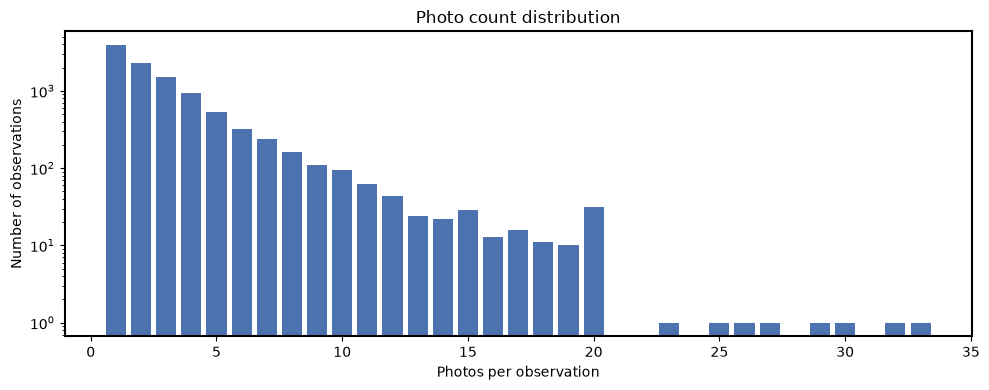

In [33]:
# Distribution of photo count per observation
import matplotlib.pyplot as plt

photo_counts = clean_obs["photo_count"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(photo_counts.index, photo_counts.values, color="#4C72B0")

ax.set_xlabel("Photos per observation")
ax.set_ylabel("Number of observations")
ax.set_title("Photo count distribution")
ax.set_yscale("log")

# Show all four borders
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


In [34]:
print(f"Total images: {obs['photo_count'].sum()}")


Total images: 30315


In [35]:
obs["photo_count"].describe()

count    10387.000000
mean         2.918552
std          2.801287
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max         33.000000
Name: photo_count, dtype: float64

## Taxonomic composition

In [36]:
clean_obs.head()

,obs_id,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,common_name,latitude,longitude,...,genus_name,species_name,subspecies_name,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name
0,55574,http://www.inaturalist.org/observations/55574,research,cc-by,predator,Korthalsella complanata,species,Kaumahana,21.317598,-157.743287,...,NaN,Korthalsella complanata,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,55575,http://www.inaturalist.org/observations/55575,research,cc-by,prey,Syzygium sandwicense,species,ʻōhiʻa ha,21.317598,-157.743287,...,NaN,Syzygium sandwicense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,338604,http://conabio.inaturalist.org/observations/33...,research,cc-by-nc,predator,Geococcyx californianus,species,Greater Roadrunner,25.557155,-103.453939,...,NaN,Geococcyx californianus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,414645,http://www.inaturalist.org/observations/414645,research,cc-by,predator,Lycophidion capense,species,Cape Wolf Snake,-15.836848,29.146428,...,NaN,Lycophidion capense,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,414707,http://www.inaturalist.org/observations/414707,research,cc-by,prey,Mochlus sundevallii,species,Sundevall's Writhing Skink,-15.836848,29.146428,...,NaN,Mochlus sundevallii,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Unique count in each ranks?

In [37]:
def unique_ranks(df):
    ranks = [
        "kingdom_name",
        "phylum_name",
        "class_name",
        "order_name",
        "family_name",
        "genus_name",
        "species_name",
    ]

    for rank in ranks:
        print(f"Unique {rank.replace('_name', '').capitalize()}: {df[rank].nunique()}")


unique_ranks(clean_obs)

Unique Kingdom: 7
Unique Phylum: 18
Unique Class: 50
Unique Order: 222
Unique Family: 803
Unique Genus: 83
Unique Species: 3956


### What percentage of observations belong to each major class/order/family?

In [38]:
def percentage_obs_ranks(df, rank_name, count=None):
    rank = (
        df[rank_name]
        .value_counts()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )
    rank["percentage"] = round((rank["count"] / df.shape[0]) * 100, 2)
    display(rank.head(count) if count is not None else rank)


In [39]:
percentage_obs_ranks(clean_obs, "kingdom_name")

,kingdom_name,count,percentage
0,Animalia,8221,79.15
1,Plantae,1833,17.65
2,Fungi,328,3.16
3,Chromista,2,0.02
4,Bacteria,1,0.01
5,Protozoa,1,0.01
6,Viruses,1,0.01


In [40]:
percentage_obs_ranks(clean_obs, "phylum_name", 5)

,phylum_name,count,percentage
0,Chordata,4378,42.15
1,Arthropoda,3667,35.30
2,Tracheophyta,1833,17.65
3,Ascomycota,279,2.69
4,Mollusca,84,0.81


In [41]:
percentage_obs_ranks(clean_obs, "class_name", 5)

,class_name,count,percentage
0,Insecta,2807,27.02
1,Aves,2803,26.99
2,Magnoliopsida,1754,16.89
3,Arachnida,732,7.05
4,Mammalia,572,5.51


In [42]:
percentage_obs_ranks(clean_obs, "order_name", 5)

,order_name,count,percentage
0,Passeriformes,977,9.41
1,Lepidoptera,842,8.11
2,Hymenoptera,791,7.62
3,Araneae,565,5.44
4,Squamata,451,4.34


In [43]:
percentage_obs_ranks(clean_obs, "family_name", 5)

,family_name,count,percentage
0,Apidae,393,3.78
1,Ebenaceae,315,3.03
2,Asteraceae,241,2.32
3,Laridae,236,2.27
4,Accipitridae,228,2.20


In [44]:
percentage_obs_ranks(clean_obs, "genus_name", 5)

,genus_name,count,percentage
0,Bombus,6,0.06
1,Lepomis,5,0.05
2,Agelenopsis,5,0.05
3,Lucilia,4,0.04
4,Oncorhynchus,4,0.04


In [45]:
percentage_obs_ranks(clean_obs, "species_name", 5)

,species_name,count,percentage
0,Diospyros virginiana,287,2.76
1,Pseudocercospora fuliginosa,166,1.60
2,Apis mellifera,155,1.49
3,Aceria theospyri,115,1.11
4,Halcyon albiventris,108,1.04


In [46]:
class_counts = (
    clean_obs.dropna(subset=["class_name"])
    .groupby("class_name")["obs_id"]
    .nunique()
    .sort_values(ascending=False)
)

top_n = 12
class_plot = pd.concat(
    [
        class_counts.head(top_n),
        pd.Series({"Other": class_counts.iloc[top_n:].sum()}),
    ]
)


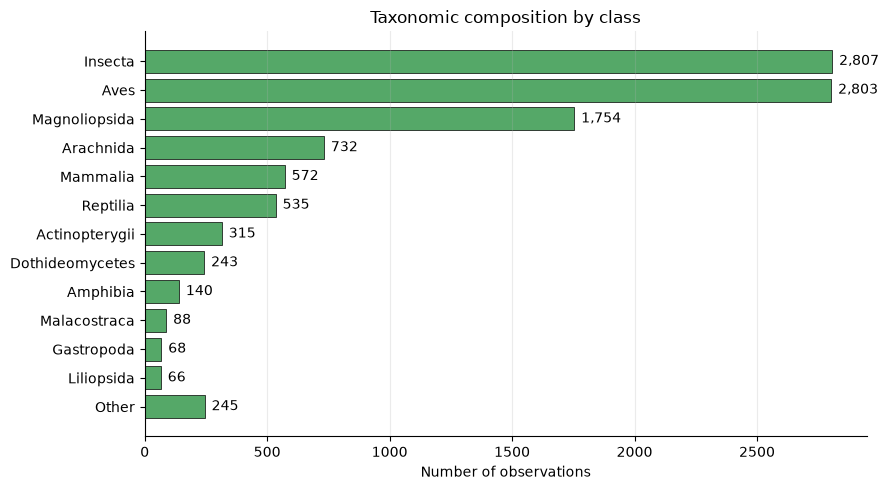

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    class_plot.index,
    class_plot.values,
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()
ax.set_xlabel("Number of observations")
ax.set_title("Taxonomic composition by class")

for bar, count in zip(bars, class_plot.values):
    ax.text(
        count + class_plot.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### What are the observation and photo count distribution under animalia for each phylum?

In [48]:
clean_obs[clean_obs["kingdom_name"] == "Animalia"]["phylum_name"].unique()

<ArrowStringArray>
[       'Chordata',      'Arthropoda',   'Echinodermata',        'Mollusca',
        'Cnidaria',        'Nemertea',        'Annelida', 'Platyhelminthes',
     'Onychophora']
Length: 9, dtype: str

In [49]:
animalia = clean_obs[clean_obs["kingdom_name"] == "Animalia"]
print(f"Observation distribution per phylum under animalia")
animalia.groupby("phylum_name").size().sort_values(ascending=False)

Observation distribution per phylum under animalia


phylum_name
Chordata           4378
Arthropoda         3667
Mollusca             84
Echinodermata        59
Onychophora          11
Platyhelminthes       8
Cnidaria              8
Annelida              5
Nemertea              1
dtype: int64

In [50]:
animalia = clean_obs[clean_obs["kingdom_name"] == "Animalia"]
print(f"Photo count distribution per phylum under animalia")
animalia.groupby("phylum_name")["photo_count"].sum().sort_values(ascending=False)

Photo count distribution per phylum under animalia


phylum_name
Chordata           13404
Arthropoda         10622
Mollusca             241
Echinodermata         79
Onychophora           38
Cnidaria              30
Platyhelminthes       22
Annelida              17
Nemertea               4
Name: photo_count, dtype: int64

### What percentage of images belong to each major kingdom and phylum group?
Major = Kingdom, Phylym, Class

In [51]:
def per_img_rank(df, rank_name, count=None):
    rank = (
        df.groupby(rank_name)["photo_count"]
        .sum()
        .sort_values(ascending=False)
        .reset_index(name="count")
    )
    display(rank.head(count) if count is not None else rank)

In [52]:
per_img_rank(clean_obs, "kingdom_name")

,kingdom_name,count
0,Animalia,24457
1,Plantae,5205
2,Fungi,640
3,Chromista,5
4,Protozoa,4
5,Bacteria,3
6,Viruses,1


In [53]:
per_img_rank(clean_obs, "phylum_name", 5)

,phylum_name,count
0,Chordata,13404
1,Arthropoda,10622
2,Tracheophyta,5205
3,Ascomycota,485
4,Mollusca,241


### How many species have:- 1 observation, 2 to 5 observations, 6 to 10, 11 to 50, 50

In [54]:
obs_per_species = (
    clean_obs.groupby("species_name")
    .size()
    .reset_index(name="observation_count")
    .sort_values(by="observation_count", ascending=False)
)

obs_per_species

,species_name,observation_count
1189,Diospyros virginiana,287
3022,Pseudocercospora fuliginosa,166
282,Apis mellifera,155
40,Aceria theospyri,115
1633,Halcyon albiventris,108
...,...,...
1428,Euplectes axillaris,1
1426,Euphydryas chalcedona,1
1425,Euphoria sepulcralis,1
3951,Zygaena ephialtes,1


In [55]:
one_obs = obs_per_species[obs_per_species["observation_count"] == 1][
    "species_name"
].nunique()
print(f"Number of species with only one observation: {one_obs}")

Number of species with only one observation: 2526


In [56]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 2)
    & (obs_per_species["observation_count"] <= 5)
]["species_name"].nunique()
print(f"Number of species with 2 to 5 observations: {one_obs}")

Number of species with 2 to 5 observations: 1146


In [57]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 6)
    & (obs_per_species["observation_count"] <= 10)
]["species_name"].nunique()
print(f"Number of species with 6 to 10 observations: {one_obs}")

Number of species with 6 to 10 observations: 188


In [58]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 11)
    & (obs_per_species["observation_count"] <= 50)
]["species_name"].nunique()
print(f"Number of species with 11 to 50 observations: {one_obs}")

Number of species with 11 to 50 observations: 85


In [59]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 51)
    & (obs_per_species["observation_count"] <= 100)
]["species_name"].nunique()
print(f"Number of species with 51 to 100 observations: {one_obs}")

Number of species with 51 to 100 observations: 6


In [60]:
one_obs = obs_per_species[
    (obs_per_species["observation_count"] >= 101)
    & (obs_per_species["observation_count"] <= 300)
]["species_name"].nunique()
print(f"Number of species with 101 to 300 observations: {one_obs}")

Number of species with 101 to 300 observations: 5


Observation per species distribution


In [61]:
import matplotlib.pyplot as plt

species_obs_counts = (
    clean_obs.dropna(subset=["species_name"])
    .groupby("species_name")["obs_id"]
    .nunique()
    .sort_values(ascending=False)
)

species_count_distribution = (
    species_obs_counts.value_counts()
    .sort_index()
    .rename_axis("observations_per_species")
    .reset_index(name="species_count")
)

print(f"Number of species: {species_obs_counts.shape[0]}")
print(f"Median observations per species: {species_obs_counts.median():.0f}")
print(f"Mean observations per species: {species_obs_counts.mean():.2f}")
print(f"Species with 1 observation: {(species_obs_counts == 1).sum()}")
print(f"Species with fewer than 5 observations: {(species_obs_counts < 5).sum()}")


Number of species: 3956
Median observations per species: 1
Mean observations per species: 2.57
Species with 1 observation: 2526
Species with fewer than 5 observations: 3573


In [62]:
display(species_count_distribution.head(10))


,observations_per_species,species_count
0,1,2526
1,2,627
2,3,277
3,4,143
4,5,99
5,6,56
6,7,50
7,8,31
8,9,30
9,10,21


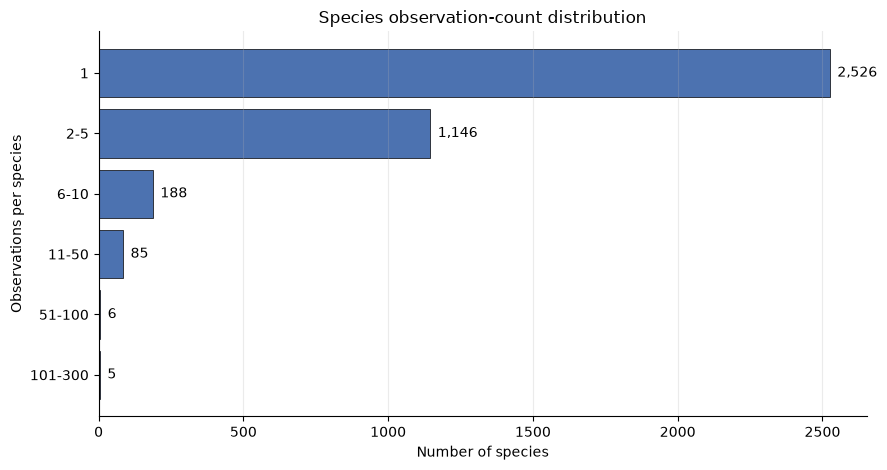

In [63]:
import matplotlib.pyplot as plt

bin_edges = [0, 1, 5, 10, 50, 100, 300]
bin_labels = ["1", "2-5", "6-10", "11-50", "51-100", "101-300"]

species_obs_bins = (
    pd.cut(
        species_obs_counts,
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
    )
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(9, 4.8))

bars = ax.barh(
    species_obs_bins.index.astype(str),
    species_obs_bins.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()

ax.set_xlabel("Number of species")
ax.set_ylabel("Observations per species")
ax.set_title("Species observation-count distribution")

for bar, count in zip(bars, species_obs_bins.values):
    ax.text(
        count + species_obs_bins.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### What proportion of all images comes from the top 1%, 5%, and 10% most common species?

In [64]:
import numpy as np

# One row per species: observation count + image count
species_summary = (
    clean_obs.dropna(subset=["species_name"])
    .groupby("species_name")
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_count", "sum"),
    )
    .sort_values("observation_count", ascending=False)
)

total_images = species_summary["image_count"].sum()

for pct in [0.01, 0.05, 0.10, 0.30, 0.50]:
    n_species = max(1, int(np.ceil(len(species_summary) * pct)))
    top_images = species_summary.head(n_species)["image_count"].sum()
    image_share = top_images / total_images * 100

    print(
        f"Top {int(pct * 100)}% species "
        f"({n_species:,} species): {top_images:,} images "
        f"({image_share:.2f}% of all images)"
    )

Top 1% species (40 species): 5,517 images (18.54% of all images)
Top 5% species (198 species): 10,472 images (35.19% of all images)
Top 10% species (396 species): 13,511 images (45.41% of all images)
Top 30% species (1,187 species): 19,897 images (66.87% of all images)
Top 50% species (1,978 species): 23,148 images (77.80% of all images)


##  Predator versus prey composition

### How many observations are labeled predator and prey? What percentage is predator versus prey?

In [65]:
clean_obs["predator_prey_role"].unique()

<ArrowStringArray>
['predator', 'prey', nan]
Length: 3, dtype: str

In [66]:
pre_prey = clean_obs["predator_prey_role"].value_counts().reset_index()
pre_prey.columns = ["predator_prey_role", "count"]
pre_prey["Percentage"] = round((pre_prey["count"] / pre_prey["count"].sum()) * 100, 2)
pre_prey

,predator_prey_role,count,Percentage
0,predator,6633,64.81
1,prey,3601,35.19


### How many observations with no roles and which taxa rank govern it?

In [67]:
no_roles = clean_obs[clean_obs["predator_prey_role"].isna()]
no_roles.shape

(153, 27)

In [68]:
no_roles["kingdom_name"].value_counts()

kingdom_name
Animalia    153
Name: count, dtype: int64

In [69]:
no_roles["phylum_name"].value_counts()

phylum_name
Chordata      86
Arthropoda    67
Name: count, dtype: int64

In [70]:
no_roles["class_name"].value_counts()

class_name
Insecta      65
Mammalia     40
Aves         23
Reptilia     22
Arachnida     2
Amphibia      1
Name: count, dtype: int64

### Are some taxa disproportionately represented as predator or prey?

In [71]:
role_col = "predator_prey_role"

role_df = clean_obs.dropna(subset=[role_col]).copy()

# Optional: keep only the two main roles if your column has other values
role_df = role_df[role_df[role_col].isin(["predator", "prey"])]

In [72]:
# 1. Are some taxa disproportionately represented as predator or prey?

taxa_role_summary = (
    role_df.groupby([role_col, "phylum_name"])
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_count", "sum"),
        species_count=("species_name", "nunique"),
    )
    .reset_index()
)


In [73]:
phylum_role_obs = taxa_role_summary.pivot(
    index="phylum_name",
    columns=role_col,
    values="observation_count",
).fillna(0)

phylum_role_obs["total"] = phylum_role_obs.sum(axis=1)
phylum_role_obs["predator_share"] = (
    phylum_role_obs.get("predator", 0) / phylum_role_obs["total"] * 100
)
phylum_role_obs["prey_share"] = (
    phylum_role_obs.get("prey", 0) / phylum_role_obs["total"] * 100
)

phylum_role_obs.sort_values("total", ascending=False)

predator_prey_role,predator,prey,total,predator_share,prey_share
phylum_name,,,,,
Chordata,3361.0,931.0,4292.0,78.308481,21.691519
Arthropoda,2828.0,772.0,3600.0,78.555556,21.444444
Tracheophyta,53.0,1780.0,1833.0,2.891435,97.108565
Ascomycota,275.0,4.0,279.0,98.566308,1.433692
Mollusca,50.0,34.0,84.0,59.523810,40.476190
Echinodermata,3.0,56.0,59.0,5.084746,94.915254
Basidiomycota,30.0,15.0,45.0,66.666667,33.333333
Onychophora,9.0,2.0,11.0,81.818182,18.181818
Platyhelminthes,8.0,0.0,8.0,100.000000,0.000000


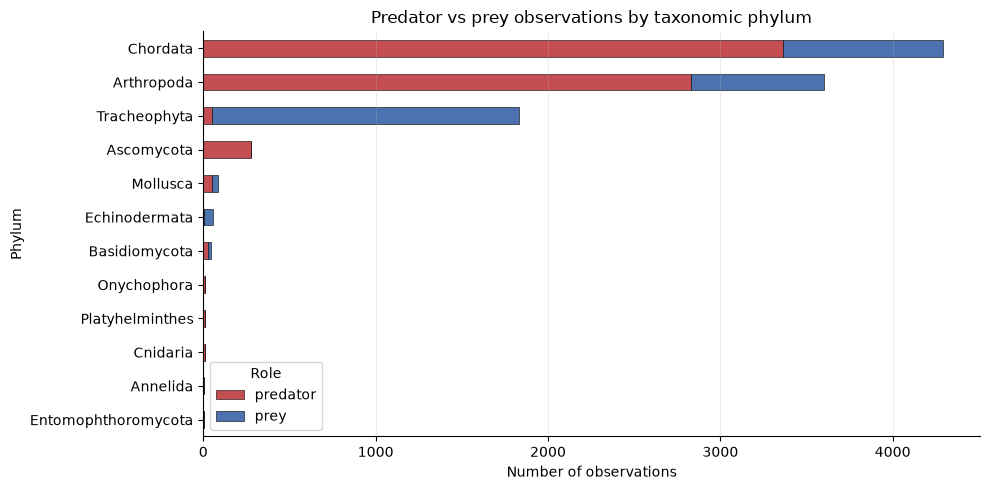

In [74]:
top_classes = phylum_role_obs.sort_values("total", ascending=False).head(12).index

plot_df = phylum_role_obs.loc[top_classes, ["predator", "prey"]]

fig, ax = plt.subplots(figsize=(10, 5))

plot_df.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["#C44E52", "#4C72B0"],
    edgecolor="black",
    linewidth=0.4,
)

ax.invert_yaxis()
ax.set_xlabel("Number of observations")
ax.set_ylabel("Phylum")
ax.set_title("Predator vs prey observations by taxonomic phylum")
ax.legend(title="Role")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Is taxonomic diversity similar across the two roles?

In [75]:
taxonomic_diversity_by_role = role_df.groupby(role_col).agg(
    observations=("obs_id", "nunique"),
    images=("photo_count", "sum"),
    classes=("class_name", "nunique"),
    orders=("order_name", "nunique"),
    families=("family_name", "nunique"),
    genera=("genus_name", "nunique"),
    species=("species_name", "nunique"),
)

taxonomic_diversity_by_role

,observations,images,classes,orders,families,genera,species
predator_prey_role,,,,,,,
predator,6633,19766,31,138,480,54,2417
prey,3601,10284,39,175,539,35,1790


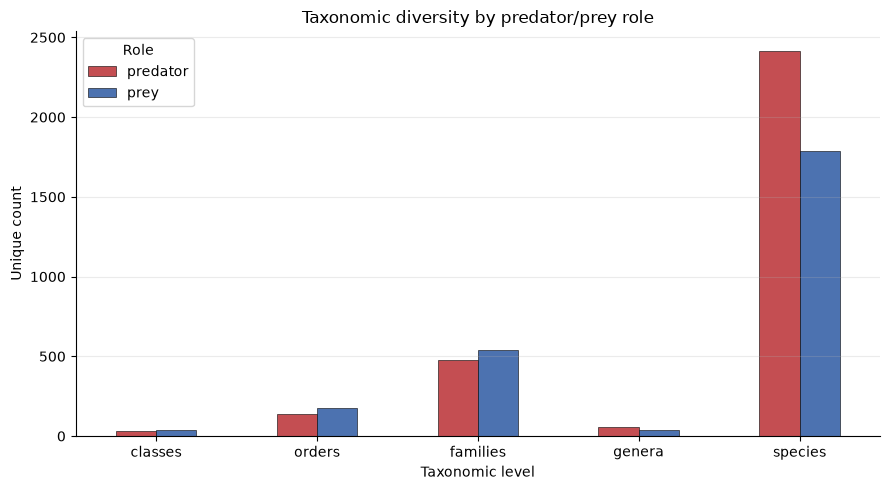

In [76]:
diversity_plot = taxonomic_diversity_by_role[
    ["classes", "orders", "families", "genera", "species"]
].T

fig, ax = plt.subplots(figsize=(9, 5))

diversity_plot.plot(
    kind="bar",
    ax=ax,
    color=["#C44E52", "#4C72B0"],
    edgecolor="black",
    linewidth=0.4,
)

ax.set_xlabel("Taxonomic level")
ax.set_ylabel("Unique count")
ax.set_title("Taxonomic diversity by predator/prey role")
ax.legend(title="Role")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Is image count balanced between predator and prey?

In [77]:
image_balance_by_role = role_df.groupby(role_col).agg(
    observations=("obs_id", "nunique"),
    images=("photo_count", "sum"),
    mean_images_per_observation=("photo_count", "mean"),
    median_images_per_observation=("photo_count", "median"),
)

image_balance_by_role["image_share_percent"] = (
    image_balance_by_role["images"] / image_balance_by_role["images"].sum() * 100
)

image_balance_by_role

,observations,images,mean_images_per_observation,median_images_per_observation,image_share_percent
predator_prey_role,,,,,
predator,6633,19766,2.979949,2.0,65.777038
prey,3601,10284,2.855873,2.0,34.222962


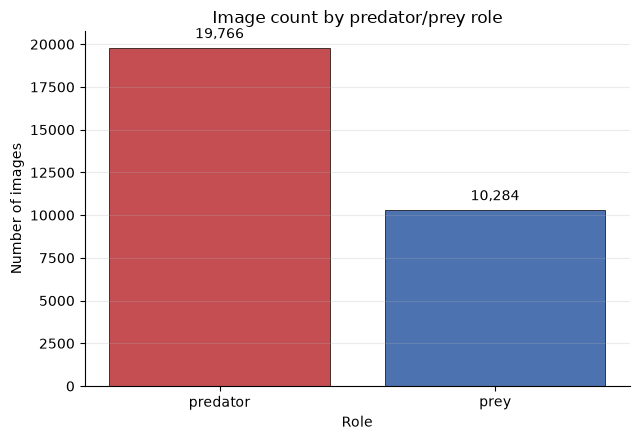

In [78]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

bars = ax.bar(
    image_balance_by_role.index,
    image_balance_by_role["images"],
    color=["#C44E52", "#4C72B0"],
    edgecolor="black",
    linewidth=0.5,
)

ax.set_xlabel("Role")
ax.set_ylabel("Number of images")
ax.set_title("Image count by predator/prey role")

for bar, count in zip(bars, image_balance_by_role["images"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count + image_balance_by_role["images"].max() * 0.02,
        f"{int(count):,}",
        ha="center",
        va="bottom",
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## Geographic coverage


#### Get the geographic information

In [79]:
from gazetteer import Gazetteer

In [80]:
def reverse_geocode_locations(
    df: pd.DataFrame,
    latitude_col: str = "latitude",
    longitude_col: str = "longitude",
) -> pd.DataFrame:

    # Keep only unique coordinate combinations
    locations = df[[latitude_col, longitude_col]].dropna().drop_duplicates().copy()

    # Gazetteer expects (longitude, latitude)
    coordinates = list(zip(locations[longitude_col], locations[latitude_col]))

    gz = Gazetteer()

    results = []

    for data in gz.search(coordinates):
        if data.result is None:
            results.append(
                {
                    latitude_col: data.lat,
                    longitude_col: data.lon,
                    "country": None,
                    "state": None,
                    "city": None,
                }
            )
        else:
            results.append(
                {
                    latitude_col: data.lat,
                    longitude_col: data.lon,
                    "country": data.result.admin1,
                    "state": data.result.admin2,
                    "city": data.result.name,
                }
            )

    location_lookup = pd.DataFrame(results)

    # Join geographic information back into original dataframe
    result_df = df.merge(location_lookup, on=[latitude_col, longitude_col], how="left")

    return result_df

In [81]:
geo = pd.DataFrame(columns=["latitude", "longitude"])
geo["latitude"] = clean_obs["latitude"]
geo["longitude"] = clean_obs["longitude"]
geo.shape

(10387, 2)

In [82]:
geo_nodup = geo.drop_duplicates()
geo_nodup.shape

(8471, 2)

In [83]:
df = reverse_geocode_locations(
    geo_nodup, latitude_col="latitude", longitude_col="longitude"
)

print(df[["latitude", "longitude", "country", "state", "city"]].head())

    latitude   longitude        country                      state        city
0  21.317598 -157.743287  United States                     Hawaii    Honolulu
1  25.557155 -103.453939            NaN                        NaN         NaN
2 -15.836848   29.146428       Zimbabwe  Mashonaland West Province  Hurungwe 7
3  35.902263  -79.086335  United States             North Carolina      Orange
4  30.085165  -97.840715  United States                      Texas        Hays


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8471 entries, 0 to 8470
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   8470 non-null   float64
 1   longitude  8470 non-null   float64
 2   country    7473 non-null   str    
 3   state      7473 non-null   str    
 4   city       7473 non-null   str    
dtypes: float64(2), str(3)
memory usage: 552.7 KB


In [ ]:
import reverse_geocode


def fill_missing_locations(df):
    df = df.copy()

    # Keep track of rows that need fallback values
    missing_mask = df["country"].isna() | df["state"].isna() | df["city"].isna()

    missing = df.loc[missing_mask, ["latitude", "longitude"]].copy()

    # Force coordinates to numeric
    missing["latitude"] = pd.to_numeric(missing["latitude"], errors="coerce")

    missing["longitude"] = pd.to_numeric(missing["longitude"], errors="coerce")

    # Remove NaN and +/- inf coordinates
    valid_mask = np.isfinite(missing["latitude"]) & np.isfinite(missing["longitude"])

    valid_missing = missing.loc[valid_mask].copy()

    print(f"Missing location rows: {len(missing)}")
    print(f"Valid coordinates for fallback: {len(valid_missing)}")
    print(f"Invalid coordinates skipped: {(~valid_mask).sum()}")

    if valid_missing.empty:
        return df

    coords = list(zip(valid_missing["latitude"], valid_missing["longitude"]))

    results = reverse_geocode.search(coords)

    fallback = pd.DataFrame(results)

    fallback["latitude"] = valid_missing["latitude"].values
    fallback["longitude"] = valid_missing["longitude"].values

    fallback = fallback[["latitude", "longitude", "country", "state", "city"]]

    # Avoid duplicate coordinate rows before merging
    fallback = fallback.drop_duplicates(subset=["latitude", "longitude"])

    df = df.merge(
        fallback, on=["latitude", "longitude"], how="left", suffixes=("", "_fallback")
    )

    for col in ["country", "state", "city"]:
        df[col] = df[col].fillna(df[f"{col}_fallback"])

    df = df.drop(columns=["country_fallback", "state_fallback", "city_fallback"])

    return df

In [90]:
df = fill_missing_locations(df)

Missing location rows: 998
Valid coordinates for fallback: 997
Invalid coordinates skipped: 1


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8471 entries, 0 to 8470
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   8470 non-null   float64
 1   longitude  8470 non-null   float64
 2   country    8470 non-null   str    
 3   state      8460 non-null   str    
 4   city       8470 non-null   str    
dtypes: float64(2), str(3)
memory usage: 582.6 KB


### Store the geographical information in the main df

In [109]:
clean_obs["temp"] = (
    clean_obs["latitude"].astype(str) + "_" + clean_obs["longitude"].astype(str)
)

clean_obs["temp"].shape

(10387,)

In [110]:
clean_obs["temp"].info()

<class 'pandas.Series'>
RangeIndex: 10387 entries, 0 to 10386
Series name: temp
Non-Null Count  Dtype
--------------  -----
10371 non-null  str  
dtypes: str(1)
memory usage: 339.8 KB


In [111]:
clean_obs[clean_obs["temp"].isna()].head()

,obs_id,obs_url,quality_grade,obs_license_code,predator_prey_role,scientific_name,taxon_rank,common_name,latitude,longitude,...,species_name,subspecies_name,subfamily_name,hybrid_name,complex_name,form_name,subgenus_name,variety_name,tribe_name,temp
445,25409558,https://www.inaturalist.org/observations/25409558,research,cc-by-nc,predator,Pantherophis alleghaniensis,species,Central Ratsnake,NaN,NaN,...,Pantherophis alleghaniensis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1934,93272373,https://www.inaturalist.org/observations/93272373,research,cc-by-nc,predator,Anolis carolinensis,species,Green Anole,NaN,NaN,...,Anolis carolinensis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3769,178838432,https://www.inaturalist.org/observations/17883...,research,cc-by-nc,predator,Trichonephila clavipes,species,Golden Silk Spider,NaN,NaN,...,Trichonephila clavipes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3865,182961224,https://www.inaturalist.org/observations/18296...,research,cc-by,predator,Angelica sylvestris,species,Wild Angelica,NaN,NaN,...,Angelica sylvestris,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4445,198669694,https://www.inaturalist.org/observations/19866...,research,cc-by-nc,predator,Anolis carolinensis,species,Green Anole,NaN,NaN,...,Anolis carolinensis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [112]:
df = df[df["latitude"].notna()]

In [104]:
df.shape

(8470, 5)

In [113]:
df["temp"] = df["latitude"].astype(str) + "_" + df["longitude"].astype(str)

df["temp"].shape

(8470,)

In [114]:
df["temp"].duplicated().sum()

np.int64(0)

In [115]:
clean_obs = clean_obs.merge(
    df[["temp", "country", "state", "city"]].drop_duplicates("temp"),
    on="temp",
    how="left",
)
clean_obs.info()

<class 'pandas.DataFrame'>
RangeIndex: 10387 entries, 0 to 10386
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   obs_id               10387 non-null  int64  
 1   obs_url              10387 non-null  str    
 2   quality_grade        10387 non-null  str    
 3   obs_license_code     10387 non-null  str    
 4   predator_prey_role   10234 non-null  str    
 5   scientific_name      10387 non-null  str    
 6   taxon_rank           10387 non-null  str    
 7   common_name          9449 non-null   str    
 8   latitude             10371 non-null  float64
 9   longitude            10371 non-null  float64
 10  positional_accuracy  8165 non-null   float64
 11  photo_count          10387 non-null  int64  
 12  kingdom_name         10387 non-null  str    
 13  phylum_name          10387 non-null  str    
 14  class_name           10368 non-null  str    
 15  order_name           10374 non-null  str    
 1

In [118]:
clean_obs[clean_obs["state"].isna() & clean_obs["city"].notna()][
    ["country", "state", "city"]
]

,country,state,city
1591,Falkland Islands (Malvinas),NaN,Stanley
3347,South Georgia and the South Sandwich Islands,NaN,Grytviken
4320,Singapore,NaN,Oxley
4322,Singapore,NaN,Oxley
6088,Singapore,NaN,Thomson
6089,Singapore,NaN,Thomson
6090,Singapore,NaN,Thomson
6324,Singapore,NaN,Lucky Hills
7903,Singapore,NaN,Punggol
8758,Singapore,NaN,Thomson


In [119]:
clean_obs = clean_obs.drop(columns=["temp"])
clean_obs.info()

<class 'pandas.DataFrame'>
RangeIndex: 10387 entries, 0 to 10386
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   obs_id               10387 non-null  int64  
 1   obs_url              10387 non-null  str    
 2   quality_grade        10387 non-null  str    
 3   obs_license_code     10387 non-null  str    
 4   predator_prey_role   10234 non-null  str    
 5   scientific_name      10387 non-null  str    
 6   taxon_rank           10387 non-null  str    
 7   common_name          9449 non-null   str    
 8   latitude             10371 non-null  float64
 9   longitude            10371 non-null  float64
 10  positional_accuracy  8165 non-null   float64
 11  photo_count          10387 non-null  int64  
 12  kingdom_name         10387 non-null  str    
 13  phylum_name          10387 non-null  str    
 14  class_name           10368 non-null  str    
 15  order_name           10374 non-null  str    
 1

### How many countries are represented?

In [122]:
country_dist = (
    clean_obs.groupby("country")
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)
country_dist

,country,count
112,United States,5060
92,South Africa,1209
118,Zimbabwe,510
104,Thailand,447
15,Canada,329
...,...,...
108,Turkey,1
107,Trinidad and Tobago,1
113,Uruguay,1
114,Vanuatu,1


### What are the top 5 countries by observation count and their percentages?

In [125]:
country_dist["percentage"] = round(
    (country_dist["count"] / country_dist["count"].sum()) * 100, 2
)
country_dist.head()

,country,count,percentage
112,United States,5060,48.79
92,South Africa,1209,11.66
118,Zimbabwe,510,4.92
104,Thailand,447,4.31
15,Canada,329,3.17


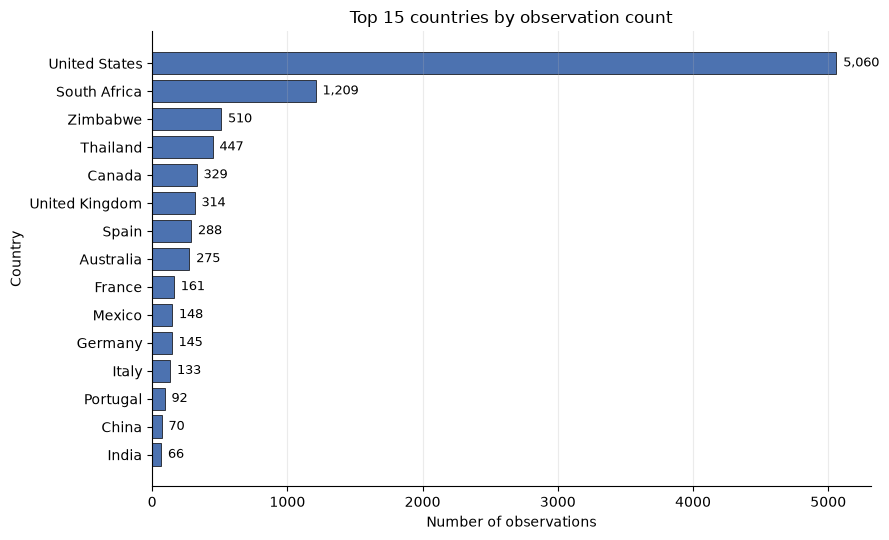

In [126]:
import matplotlib.pyplot as plt

top_n = 15

country_plot = country_dist.sort_values("count", ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    country_plot["country"],
    country_plot["count"],
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()

ax.set_xlabel("Number of observations")
ax.set_ylabel("Country")
ax.set_title(f"Top {top_n} countries by observation count")

for bar, count in zip(bars, country_plot["count"]):
    ax.text(
        count + country_plot["count"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,}",
        va="center",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### How geographically concentrated is the dataset?


In [127]:
country_col = "country"
obs_col = "obs_id"

In [128]:
# Geographic analysis dataframe

geo_df = clean_obs.copy()

geo_df[country_col] = (
    geo_df[country_col]
    .astype("string")
    .str.strip()
    .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
)

usable_geo_df = geo_df.dropna(subset=[country_col])

In [129]:
# How geographically concentrated is the dataset?

country_dist = (
    usable_geo_df.groupby(country_col)
    .agg(
        observation_count=(obs_col, "nunique"),
        image_count=("photo_count", "sum"),
        species_count=("species_name", "nunique"),
        class_count=("class_name", "nunique"),
        order_count=("order_name", "nunique"),
    )
    .sort_values("observation_count", ascending=False)
    .reset_index()
)

total_geo_observations = country_dist["observation_count"].sum()

country_dist["observation_share_percent"] = (
    country_dist["observation_count"] / total_geo_observations * 100
)

country_dist["cumulative_share_percent"] = country_dist[
    "observation_share_percent"
].cumsum()

print(f"Countries represented: {country_dist.shape[0]:,}")
print(
    f"Top 1 country share: {country_dist.head(1)['observation_share_percent'].sum():.2f}%"
)
print(
    f"Top 5 countries share: {country_dist.head(5)['observation_share_percent'].sum():.2f}%"
)
print(
    f"Top 10 countries share: {country_dist.head(10)['observation_share_percent'].sum():.2f}%"
)

country_dist.head(15)

Countries represented: 119
Top 1 country share: 48.79%
Top 5 countries share: 72.85%
Top 10 countries share: 84.28%


,country,observation_count,image_count,species_count,class_count,order_count,observation_share_percent,cumulative_share_percent
0,United States,5060,13500,1506,43,171,48.789895,48.789895
1,South Africa,1209,6228,602,14,81,11.657507,60.447401
2,Zimbabwe,510,1324,300,11,60,4.917559,65.364960
3,Thailand,447,1075,309,12,45,4.310095,69.675055
4,Canada,329,775,196,13,57,3.172307,72.847363
5,United Kingdom,314,830,153,13,56,3.027673,75.875036
6,Spain,288,645,204,14,57,2.776974,78.652010
7,Australia,275,783,182,12,58,2.651625,81.303635
8,France,161,326,87,10,35,1.552406,82.856041
9,Mexico,148,476,91,18,43,1.427056,84.283097


### How many observations lack usable geographic metadata?

In [131]:
missing_geo_summary = pd.Series(
    {
        "total_observations": geo_df[obs_col].nunique(),
        "observations_with_country": usable_geo_df[obs_col].nunique(),
        "observations_missing_country": geo_df[geo_df[country_col].isna()][
            obs_col
        ].nunique(),
        "percent_missing_country": (
            geo_df[geo_df[country_col].isna()][obs_col].nunique()
            / geo_df[obs_col].nunique()
            * 100
        ),
    }
)

missing_geo_summary

total_observations              10387.000000
observations_with_country       10371.000000
observations_missing_country       16.000000
percent_missing_country             0.154039
dtype: float64

### Does taxonomic richness vary by geographic region?

In [132]:
geo_richness = (
    usable_geo_df.groupby(country_col)
    .agg(
        observations=(obs_col, "nunique"),
        images=("photo_count", "sum"),
        classes=("class_name", "nunique"),
        orders=("order_name", "nunique"),
        families=("family_name", "nunique"),
        genera=("genus_name", "nunique"),
        species=("species_name", "nunique"),
    )
    .sort_values("species", ascending=False)
    .reset_index()
)

geo_richness["species_per_100_observations"] = (
    geo_richness["species"] / geo_richness["observations"] * 100
)

geo_richness.head(15)

,country,observations,images,classes,orders,families,genera,species,species_per_100_observations
0,United States,5060,13500,43,171,480,33,1506,29.762846
1,South Africa,1209,6228,14,81,236,6,602,49.793218
2,Thailand,447,1075,12,45,111,0,309,69.127517
3,Zimbabwe,510,1324,11,60,150,0,300,58.823529
4,Spain,288,645,14,57,122,3,204,70.833333
5,Canada,329,775,13,57,118,1,196,59.574468
6,Australia,275,783,12,58,117,3,182,66.181818
7,United Kingdom,314,830,13,56,93,5,153,48.726115
8,Germany,145,487,10,43,82,1,104,71.724138
9,Mexico,148,476,18,43,82,25,91,61.486486


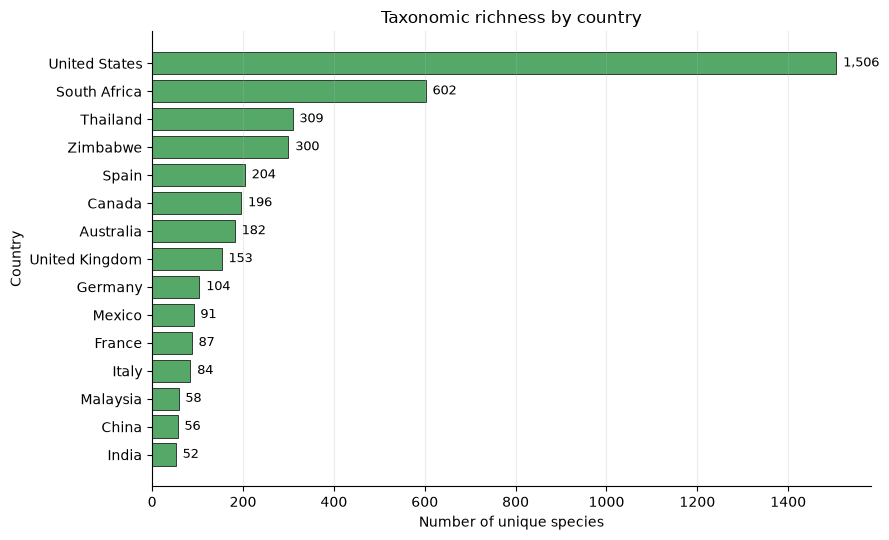

In [133]:
# Plot: species richness by country

richness_plot = geo_richness.sort_values("species", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(
    richness_plot[country_col],
    richness_plot["species"],
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

ax.invert_yaxis()
ax.set_xlabel("Number of unique species")
ax.set_ylabel("Country")
ax.set_title("Taxonomic richness by country")

for bar, count in zip(bars, richness_plot["species"]):
    ax.text(
        count + richness_plot["species"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(count):,}",
        va="center",
        fontsize=9,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

### Are certain species heavily tied to particular countries?

In [134]:
species_country = (
    usable_geo_df.dropna(subset=["species_name"])
    .groupby(["species_name", country_col])
    .agg(observation_count=(obs_col, "nunique"))
    .reset_index()
)


In [135]:
species_total = (
    species_country.groupby("species_name")["observation_count"]
    .sum()
    .rename("species_total_observations")
)


In [136]:
species_country = species_country.merge(
    species_total,
    on="species_name",
    how="left",
)


In [137]:
species_country["country_share_percent"] = (
    species_country["observation_count"]
    / species_country["species_total_observations"]
    * 100
)


In [138]:
country_tied_species = (
    species_country.sort_values(
        ["species_name", "country_share_percent", "observation_count"],
        ascending=[True, False, False],
    )
    .groupby("species_name")
    .head(1)
    .query("species_total_observations >= 5 and country_share_percent >= 80")
    .sort_values(
        ["country_share_percent", "species_total_observations"],
        ascending=False,
    )
)

print(
    "Species with at least 5 observations where >=80% of observations "
    "come from one country:",
    country_tied_species.shape[0],
)

country_tied_species.head(20)

Species with at least 5 observations where >=80% of observations come from one country: 238


,species_name,country,observation_count,species_total_observations,country_share_percent
1494,Diospyros virginiana,United States,287,287,100.0
3756,Pseudocercospora fuliginosa,United States,166,166,100.0
59,Aceria theospyri,United States,115,115,100.0
2032,Halcyon albiventris,South Africa,108,108,100.0
545,Asimina triloba,United States,97,97,100.0
3089,Omphalocera munroei,United States,86,86,100.0
3500,Phyllosticta asiminae,United States,53,53,100.0
1789,Evasterias troschelii,United States,43,43,100.0
182,Alligator mississippiensis,United States,38,38,100.0
1711,Erythemis simplicicollis,United States,38,38,100.0


###  Is the dataset overwhelmingly North American or broadly global?

In [139]:
north_america_countries = {
    "United States",
    "Canada",
    "Mexico",
    "Greenland",
    "Bermuda",
    "Saint Pierre and Miquelon",
}

country_dist["region_group"] = np.where(
    country_dist[country_col].isin(north_america_countries),
    "North America",
    "Outside North America",
)

region_summary = country_dist.groupby("region_group").agg(
    observations=("observation_count", "sum"),
    images=("image_count", "sum"),
    species=("species_count", "sum"),
    countries=(country_col, "nunique"),
)

region_summary["observation_share_percent"] = (
    region_summary["observations"] / region_summary["observations"].sum() * 100
)

region_summary

,observations,images,species,countries,observation_share_percent
region_group,,,,,
North America,5538,14754,1794,4,53.398901
Outside North America,4833,15470,3104,115,46.601099


## Long-tail and imbalance questions

In [140]:
# Species frequency summary

species_freq = (
    clean_obs.dropna(subset=["species_name"])
    .groupby("species_name")
    .agg(
        observation_count=("obs_id", "nunique"),
        image_count=("photo_count", "sum"),
    )
    .sort_values("observation_count", ascending=False)
)

total_species = species_freq.shape[0]
total_observations = species_freq["observation_count"].sum()
total_images = species_freq["image_count"].sum()

median_obs_per_species = species_freq["observation_count"].median()
pct_species_under_5_obs = (species_freq["observation_count"] < 5).mean() * 100
most_common_species_obs_share = (
    species_freq["observation_count"].max() / total_observations * 100
)

print(f"Number of species: {total_species:,}")
print(f"Median observations per species: {median_obs_per_species:.0f}")
print(f"Species with fewer than 5 observations: {pct_species_under_5_obs:.2f}%")
print(f"Most common species observation share: {most_common_species_obs_share:.2f}%")

species_freq.head(10)

Number of species: 3,956
Median observations per species: 1
Species with fewer than 5 observations: 90.32%
Most common species observation share: 2.82%


,observation_count,image_count
species_name,,
Diospyros virginiana,287,620
Pseudocercospora fuliginosa,166,236
Apis mellifera,155,329
Aceria theospyri,115,233
Halcyon albiventris,108,462
Asimina triloba,97,199
Pandion haliaetus,93,274
Ardea herodias,87,345
Omphalocera munroei,86,148


### What is the Gini coefficient or another concentration statistic for species frequency?

In [141]:
# Gini coefficient for species observation frequency


def gini(values):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    if values.size == 0:
        return np.nan

    if np.any(values < 0):
        raise ValueError("Gini coefficient is not defined for negative values.")

    if values.sum() == 0:
        return 0

    sorted_values = np.sort(values)
    n = sorted_values.size
    cumulative = np.cumsum(sorted_values)

    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n


species_obs_gini = gini(species_freq["observation_count"])
species_image_gini = gini(species_freq["image_count"])

print(f"Gini coefficient, observations per species: {species_obs_gini:.3f}")
print(f"Gini coefficient, images per species: {species_image_gini:.3f}")

Gini coefficient, observations per species: 0.527
Gini coefficient, images per species: 0.607


### Image-level vs observation-level vs species-level distribution

In [142]:
# Image-level vs observation-level vs species-level distribution

distribution_summary = pd.DataFrame(
    {
        "level": ["Image-level", "Observation-level", "Species-level"],
        "unit_count": [
            total_images,
            total_observations,
            total_species,
        ],
        "median_per_species": [
            species_freq["image_count"].median(),
            species_freq["observation_count"].median(),
            1,
        ],
        "mean_per_species": [
            species_freq["image_count"].mean(),
            species_freq["observation_count"].mean(),
            1,
        ],
        "gini_by_species": [
            species_image_gini,
            species_obs_gini,
            0,
        ],
    }
)

distribution_summary

,level,unit_count,median_per_species,mean_per_species,gini_by_species
0,Image-level,29755,4.0,7.521486,0.607281
1,Observation-level,10164,1.0,2.569262,0.526652
2,Species-level,3956,1.0,1.000000,0.000000


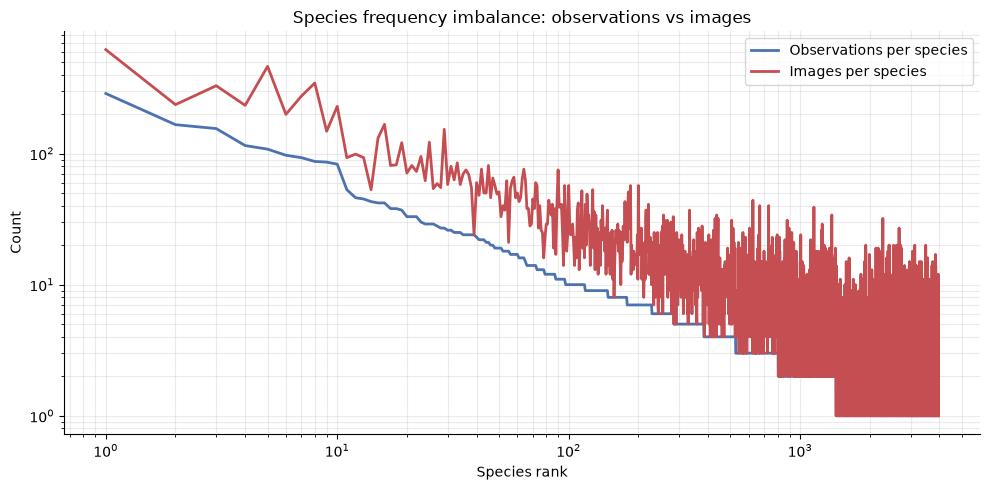

In [146]:
# Plot: image-level vs observation-level species imbalance

plot_df = species_freq.reset_index(drop=True).copy()
plot_df["species_rank"] = np.arange(1, len(plot_df) + 1)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    plot_df["species_rank"],
    plot_df["observation_count"],
    label="Observations per species",
    color="#4C72B0",
    linewidth=2,
)

ax.plot(
    plot_df["species_rank"],
    plot_df["image_count"],
    label="Images per species",
    color="#C44E52",
    linewidth=2,
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Species rank")
ax.set_ylabel("Count")
ax.set_title("Species frequency imbalance: observations vs images")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(True, which="both", alpha=0.25)

plt.tight_layout()
plt.show()

### Top species share at image and observation level

In [145]:
# Top species share at image and observation level

top_species_share = pd.DataFrame(
    {
        "metric": [
            "Top 1 species observation share",
            "Top 1 species image share",
            "Top 5 species observation share",
            "Top 5 species image share",
            "Top 10 species observation share",
            "Top 10 species image share",
        ],
        "percent": [
            species_freq.head(1)["observation_count"].sum() / total_observations * 100,
            species_freq.head(1)["image_count"].sum() / total_images * 100,
            species_freq.head(5)["observation_count"].sum() / total_observations * 100,
            species_freq.head(5)["image_count"].sum() / total_images * 100,
            species_freq.head(10)["observation_count"].sum() / total_observations * 100,
            species_freq.head(10)["image_count"].sum() / total_images * 100,
        ],
    }
)

top_species_share

,metric,percent
0,Top 1 species observation share,2.823691
1,Top 1 species image share,2.083683
2,Top 5 species observation share,8.175915
3,Top 5 species image share,6.318266
4,Top 10 species observation share,12.563951
5,Top 10 species image share,10.334398


### Which taxonomic levels are most imbalanced?

In [147]:
# Which taxonomic levels are most imbalanced?

taxonomic_levels = [
    "class_name",
    "order_name",
    "family_name",
    "genus_name",
    "species_name",
]

imbalance_rows = []

for level in taxonomic_levels:
    if level not in clean_obs.columns:
        continue

    level_counts = (
        clean_obs.dropna(subset=[level])
        .groupby(level)
        .agg(
            observation_count=("obs_id", "nunique"),
            image_count=("photo_count", "sum"),
        )
    )

    total_level_obs = level_counts["observation_count"].sum()
    total_level_images = level_counts["image_count"].sum()

    imbalance_rows.append(
        {
            "taxonomic_level": level.replace("_name", ""),
            "unique_groups": level_counts.shape[0],
            "median_observations_per_group": level_counts["observation_count"].median(),
            "max_observations_in_one_group": level_counts["observation_count"].max(),
            "top_group_observation_share_percent": (
                level_counts["observation_count"].max() / total_level_obs * 100
            ),
            "top_5_group_observation_share_percent": (
                level_counts["observation_count"]
                .sort_values(ascending=False)
                .head(5)
                .sum()
                / total_level_obs
                * 100
            ),
            "observation_gini": gini(level_counts["observation_count"]),
            "image_gini": gini(level_counts["image_count"]),
        }
    )

taxonomic_imbalance = pd.DataFrame(imbalance_rows).sort_values(
    "observation_gini", ascending=False
)

taxonomic_imbalance

,taxonomic_level,unique_groups,median_observations_per_group,max_observations_in_one_group,top_group_observation_share_percent,top_5_group_observation_share_percent,observation_gini,image_gini
0,class,50,5.5,2807,27.073688,83.603395,0.883480,0.888174
1,order,222,5.5,977,9.417775,34.952767,0.814535,0.819091
2,family,803,3.0,393,3.785762,13.611405,0.750584,0.755384
4,species,3956,1.0,287,2.823691,8.175915,0.526652,0.607281
3,genus,83,1.0,6,4.878049,19.512195,0.270742,0.407948


# Summary

In [109]:
print(f"The number of records in the dataset is {clean_obs.shape[0]}")
print(f"Final Total number of columns in the dataset: {clean_obs.shape[1]}")
print(
    f"Number of unique observations in the dataset is {clean_obs['obs_id'].nunique()}"
)
print(f"Number of images in the dataset: {clean_obs['photo_count'].sum()}")
print(f"Photo count distribution:\n{photo_count_summary}")
print(
    f"Mean photo count per observation: {photo_dist[photo_dist['statistic'] == 'mean']['photo_count'].values[0]}"
)
print(
    f"Median photo count per observation: {photo_dist[photo_dist['statistic'] == '50%']['photo_count'].values[0]}"
)
print(
    f"Maximum photo count per observation: {photo_dist[photo_dist['statistic'] == 'max']['photo_count'].values[0]}"
)
print(
    f"Minimum photo count per observation: {photo_dist[photo_dist['statistic'] == 'min']['photo_count'].values[0]}"
)

print(f"Observation license code distribution is:\n{obs_license_distribution}")
print(f"Unsupported licenses count: {unsupported_licenses_count}")
print(
    f"Missing species label count: {clean_obs[clean_obs['scientific_name'].isna() | (clean_obs['scientific_name'] == '')].shape[0]}"
)
print(
    f"Missing photos count: {clean_obs[clean_obs['photo_count'].isna() | (clean_obs['photo_count'] == 0)].shape[0]}"
)
print(f"Duplicate observations count: {clean_obs.duplicated(subset=['obs_id']).sum()}")

The number of records in the dataset is 10387
Final Total number of columns in the dataset: 27
Number of unique observations in the dataset is 10387
Number of images in the dataset: 30315
Photo count distribution:
1     3906
2     2272
3+    4209
dtype: int64
Mean photo count per observation: 2.918552036199095
Median photo count per observation: 2.0
Maximum photo count per observation: 33.0
Minimum photo count per observation: 1.0
Observation license code distribution is:
  obs_license_code  count
0         cc-by-nc   6347
1            cc-by   3212
2              cc0    543
3      cc-by-nc-nd    132
4      cc-by-nc-sa    113
5         cc-by-sa     36
6         cc-by-nd      4
Unsupported licenses count: 0
Missing species label count: 0
Missing photos count: 0
Duplicate observations count: 0


In [148]:
clean_obs.columns

Index(['obs_id', 'obs_url', 'quality_grade', 'obs_license_code',
       'predator_prey_role', 'scientific_name', 'taxon_rank', 'common_name',
       'latitude', 'longitude', 'positional_accuracy', 'photo_count',
       'kingdom_name', 'phylum_name', 'class_name', 'order_name',
       'family_name', 'genus_name', 'species_name', 'subspecies_name',
       'subfamily_name', 'hybrid_name', 'complex_name', 'form_name',
       'subgenus_name', 'variety_name', 'tribe_name', 'country', 'state',
       'city'],
      dtype='str')

In [149]:
clean_obs.shape

(10387, 30)

# save the file

In [150]:
clean_obs.to_parquet("../data/interim/clean_obs.parquet", index=False)